# Data Analysis with Python Internship - Task 4

**Author:** Rohit Kumar Verma  
**Email:** rohitkv2370@gmail.com

## Overview
This notebook demonstrates data preparation, feature engineering, and data visualization using the Titanic dataset. It satisfies the requirements for Task 4 of the Data Science Internship.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

# Set the style for seaborn
sns.set_theme(style='whitegrid')

## Data Preparation

### Load Data
We load the Titanic dataset from the `data/` folder.

In [2]:
df = pd.read_csv('data/Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Cleaning
Handling missing values: We will fill missing `Age` values with the median, drop the `Cabin` column (too many missing values), and fill `Embarked` with the mode.

In [3]:
# Fill missing Age with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Drop Cabin due to high percentage of missing values
df = df.drop(columns=['Cabin'])

# Fill Embarked with the mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

### Features
We create a new feature `FamilySize` by adding `SibSp` (siblings/spouses) and `Parch` (parents/children) plus 1 for the passenger themselves. We also create a categorical `AgeGroup` feature.

In [4]:
# Create FamilySize
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Create AgeGroup
bins = [0, 12, 18, 60, 120]
labels = ['Child', 'Teenager', 'Adult', 'Senior']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

df[['FamilySize', 'AgeGroup']].head()

,FamilySize,AgeGroup
0,2,Adult
1,2,Adult
2,1,Adult
3,2,Adult
4,1,Adult


## Visualizations

In this section, we provide 5 distinct charts to explore the dataset.

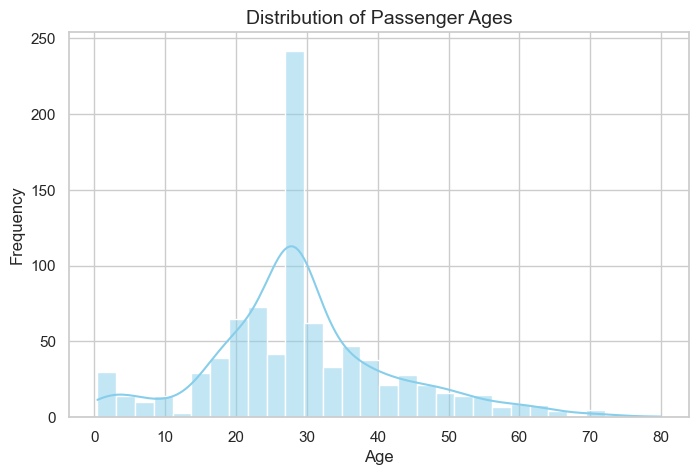

In [5]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Passenger Ages', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

**Interpretation:** The histogram shows that the majority of passengers are between 20 and 40 years old, with a notable spike in young children (under 5). The distribution is slightly right-skewed.

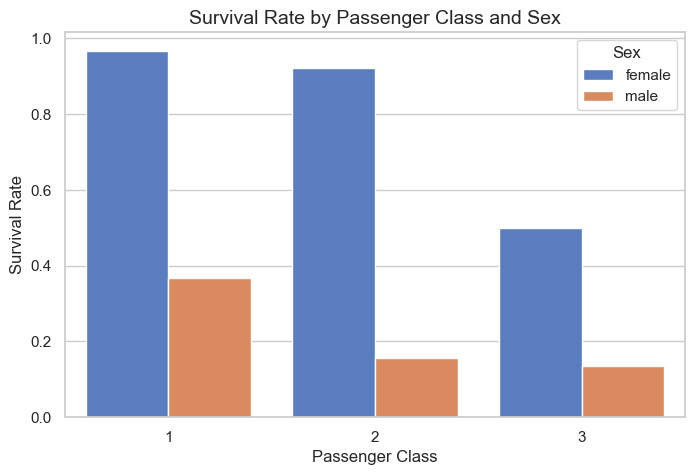

In [6]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=df, palette='muted', errorbar=None)
plt.title('Survival Rate by Passenger Class and Sex', fontsize=14)
plt.xlabel('Passenger Class', fontsize=12)
plt.ylabel('Survival Rate', fontsize=12)
plt.legend(title='Sex')
plt.show()

**Interpretation:** This bar chart reveals that females had a significantly higher survival rate across all classes compared to males. Furthermore, first-class passengers (Pclass 1) had higher survival rates than second and third-class passengers.

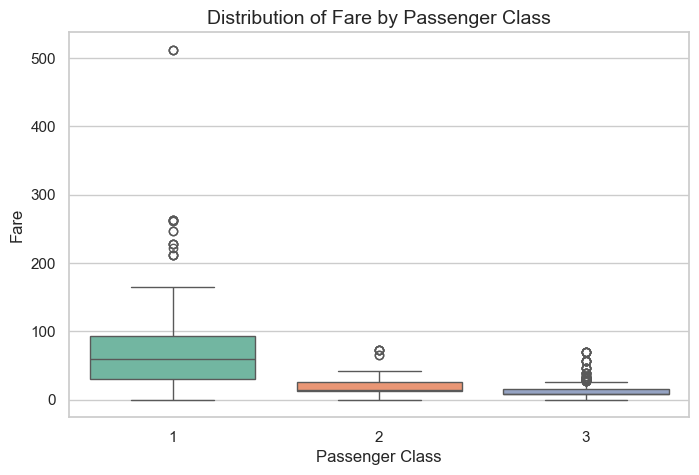

In [7]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Pclass', y='Fare', data=df, palette='Set2')
plt.title('Distribution of Fare by Passenger Class', fontsize=14)
plt.xlabel('Passenger Class', fontsize=12)
plt.ylabel('Fare', fontsize=12)
plt.show()

**Interpretation:** The boxplot illustrates that first-class fares are generally much higher and have a wider spread with many outliers. Third-class fares are consistently the lowest with minimal variance.

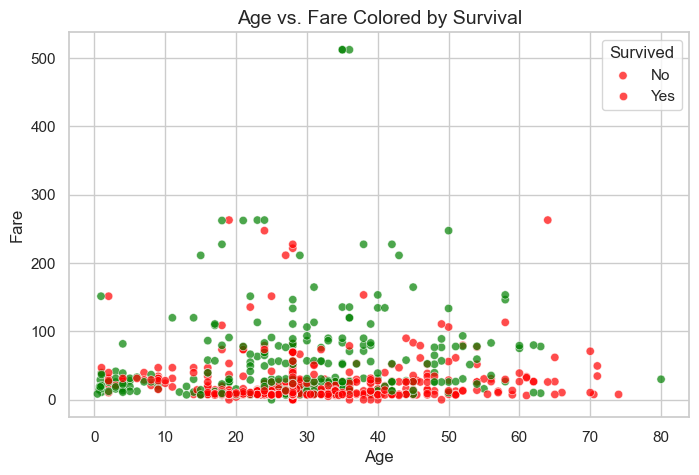

In [8]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=df, alpha=0.7, palette={0: 'red', 1: 'green'})
plt.title('Age vs. Fare Colored by Survival', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Fare', fontsize=12)
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

**Interpretation:** The scatterplot indicates a weak relationship between age and fare. However, it shows that higher fares (often associated with first class) tend to have more green dots (survivors), while lower fares have a higher concentration of red dots (non-survivors).

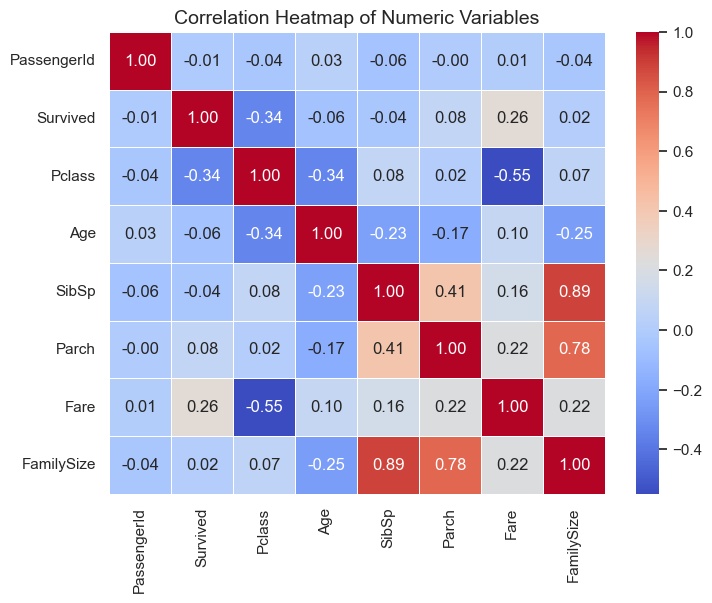

In [9]:
plt.figure(figsize=(8, 6))
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Variables', fontsize=14)
plt.show()

**Interpretation:** The heatmap highlights that `Pclass` has a strong negative correlation with `Fare` (-0.55). `Survived` has a moderate positive correlation with `Fare` (0.26) and a negative correlation with `Pclass` (-0.34).

## Insights
Based on the visualizations and analysis above, we can draw the following key insights:
- **Gender and Class matter:** Women and first-class passengers were prioritized during the rescue, leading to significantly higher survival rates for these groups.
- **Age factor:** Children had a relatively good chance of survival, whereas elderly passengers had lower survival rates.
- **Fares:** There is a clear distinction in fares among the passenger classes, and higher fares correspond to better survival odds, which ties back to the class-based survival differences.

## Conclusion
In this notebook, we successfully loaded and cleaned the Titanic dataset, addressing missing values and engineering new features (`FamilySize`, `AgeGroup`). Through a comprehensive dashboard of 5 distinct plots, we uncovered critical trends related to passenger survival. The analysis clearly demonstrates the impact of socio-economic status (Pclass/Fare) and demographics (Sex/Age) on the survival outcome during the Titanic disaster.